# Version with summing right away

In [26]:
import matplotlib.pyplot as plt
import numpy as np
spectra = []
frequency = []
velocity = []
counter = 0

spectra = {}
numSpectraPerAz = {}
file2="Azimuth30s_withCorrectCoordinates.rad"
infile=open(file2)
for line in infile.readlines():
    if ('*' not in line[0]):
        line_list = line.strip().split()
        str_spec = line_list[-64:]
        az = float(line_list[3])
        specific_spec = []
        for item in str_spec:
            specific_spec.append(float(item))
        
        summedSpectra = np.sum(specific_spec)
        # Add to this spectra to spectra dictionary's current list
        if az in spectra:
            spectra[az].append(summedSpectra)
            numSpectraPerAz[az] += 1
        else:
            spectra[az] = [summedSpectra]
            numSpectraPerAz[az] = 1
infile.close()

# Remove 27.0 azimuth entry
# Entires
if 27.0 in spectra:
    del spectra[27.0]
    
dev = []
j = 0
for i in list(spectra.keys()):
    dev.append(np.std(spectra[i]))
    j += 1
    
# Sum each list in spectra
for az in spectra:
    spectra[az] = np.sum(spectra[az])/numSpectraPerAz[az]


# Make tuples of azimuth and summed spectra
azimuths = list(spectra.keys())
summedSpectra = list(spectra.values())
# correct azimuths with cos(33.4)
for i in range(len(azimuths)): 
    azimuths[i] = azimuths[i]*np.cos(np.radians(33.4))
print(azimuths)

summedSpectraP = summedSpectra.copy()

# Subtract minimum
min_value = min(summedSpectra)
summedSpectra = [x - min_value for x in summedSpectra]

# Normalize Summed Spectra
max_value = max(summedSpectra)
summedSpectra = [x / max_value for x in summedSpectra]
max_valueP = max(summedSpectraP)
# Normalize dev
dev = [x / max_value for x in dev]


summedSpectraP = [x / max_valueP for x in summedSpectraP]

tuples = list(zip(azimuths, summedSpectra))
tuples.sort()

tuplesP = list(zip(azimuths, summedSpectraP))
tuplesP.sort()


print(tuples)
print(dev)


[np.float64(20.036348718321758), np.float64(17.531805128531538), np.float64(15.027261538741318), np.float64(12.522717948951097), np.float64(10.018174359160879), np.float64(7.513630769370659), np.float64(5.0090871795804395), np.float64(2.5045435897902197), np.float64(0.0), np.float64(-2.5045435897902197), np.float64(-5.0090871795804395), np.float64(-7.513630769370659), np.float64(-10.018174359160879), np.float64(-12.522717948951097), np.float64(-15.027261538741318), np.float64(-17.531805128531538), np.float64(-20.036348718321758)]
[(np.float64(-20.036348718321758), np.float64(0.0)), (np.float64(-17.531805128531538), np.float64(0.0011991741390044567)), (np.float64(-15.027261538741318), np.float64(0.005413482227096984)), (np.float64(-12.522717948951097), np.float64(0.007086142278177941)), (np.float64(-10.018174359160879), np.float64(0.002883342612352075)), (np.float64(-7.513630769370659), np.float64(0.011269296288429303)), (np.float64(-5.0090871795804395), np.float64(0.230546336924745)), 

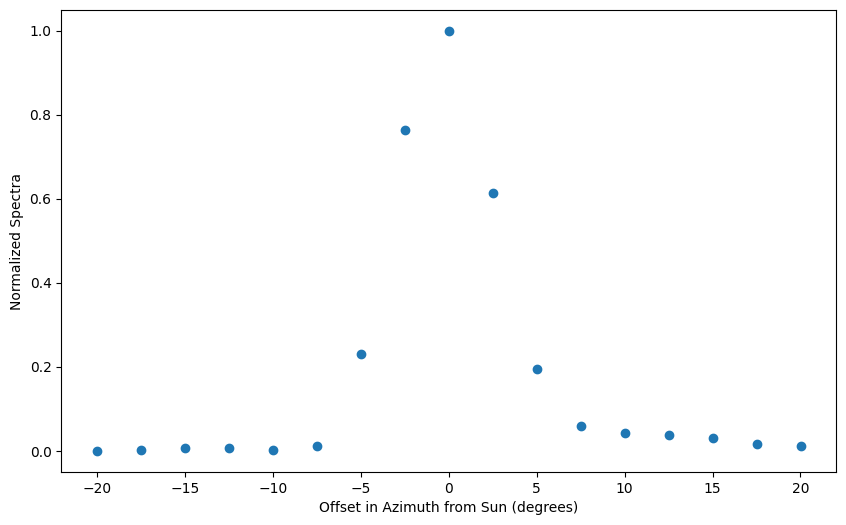

In [14]:
# Plot tuples set 
spec = []
az = []
for i in tuples:
    az.append(i[0])
    spec.append(i[1])
    
plt.figure(figsize=(10,6))
plt.xlabel('Offset in Azimuth from Sun (degrees)')
plt.ylabel('Normalized Spectra')

# Disable lines 
plt.scatter(az, spec)

In [32]:
HM = 0.5

# Calculate where the line between -6 and -3 crosses HM
slopeL = (tuples[7][1]-tuples[6][1])/(tuples[7][0]-tuples[6][0])
slopeR = (tuples[9][1]-tuples[10][1])/(tuples[9][0]-tuples[10][0])
devL = np.sqrt(((dev[7])**2 + (dev[6])**2)/2)
devR = np.sqrt((dev[9]**2 + dev[10]**2)/2)
print(dev)
print(devL, devR)

xL = ((0.5 - tuples[6][1]) / slopeL) + tuples[6][0]
xR = ((0.5 - tuples[10][1]) / slopeR) + tuples[10][0]

devL = abs(devL / slopeL)
devR = abs(devR / slopeR)

devTot = np.sqrt(devL**2 + devR**2+0.7**2)
print(xL, xR)
FWHM = abs(xL) + abs(xR)
print(FWHM) 
print("Error in FWHM: ±", devTot)

[np.float64(0.002511274625960884), np.float64(0.004330795258581377), np.float64(0.006163173928477967), np.float64(0.004704778741605136), np.float64(0.004467214260692873), np.float64(0.004973816830417887), np.float64(0.005329274041284207), np.float64(0.0048419046811426), np.float64(0.006098768947589766), np.float64(0.010181796545488684), np.float64(0.008398332616730278), np.float64(0.0029570553251417487), np.float64(0.005107140703817911), np.float64(0.010158433939797734), np.float64(0.00448543754226883), np.float64(0.003664495739538078), np.float64(0.004090324983867607)]
0.0050914242972068405 0.009332764103816215
-3.7446278944080227 3.177232319653088
6.921860214061111
Error in FWHM: ± 0.7026245567449193


In [ ]:
# adjust for elevation
el = 33.4 # on average

print(FWHM)

# print error
print(devTot)


8.291163598363507
0.02327028237053862


[(-24.0, np.float64(0.6356980917283234)), (-21.0, np.float64(0.6361349531555127)), (-18.0, np.float64(0.6376702336340496)), (-15.0, np.float64(0.6382795868825482)), (-12.0, np.float64(0.6367484989442043)), (-9.0, np.float64(0.6398035178710771)), (-6.0, np.float64(0.7196865622150529)), (-3.0, np.float64(0.9141192514002481)), (0.0, np.float64(1.0)), (3.0, np.float64(0.8588577788270322)), (6.0, np.float64(0.7061747402862888)), (9.0, np.float64(0.6567961556305367)), (12.0, np.float64(0.6514933967498266)), (15.0, np.float64(0.6497295415017997)), (18.0, np.float64(0.6466194168353624)), (21.0, np.float64(0.641179982405277)), (24.0, np.float64(0.6397951958364083))]


C:\Users\adamj\AppData\Local\Temp\ipykernel_63620\141054697.py:18: RuntimeWarning: invalid value encountered in divide
  return (2 * (sp.j1(x) / x))**2


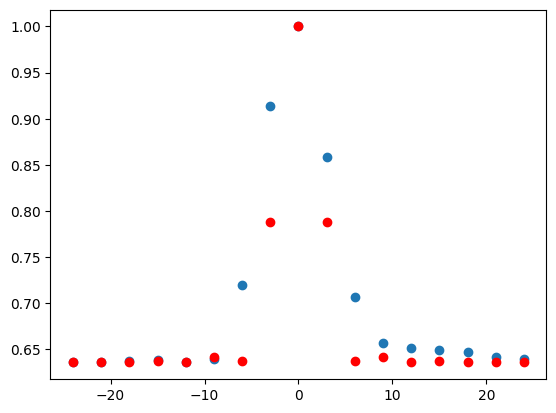

In [ ]:
# import scipy.special for Bessel function
import scipy.special as sp

# Overplot Beam Pattern using Bessel Function
# Convert 1425 MHz to meters
wavelength = 3e8 / 1425e6

x = np.pi * np.sin(np.radians(az)) * (2.3 / wavelength)
print(tuplesP)
spec = []
az = []
for i in tuplesP:
    az.append(i[0])
    spec.append(i[1])
    

def Pattern(x):
    return (2 * (sp.j1(x) / x))**2
pat = Pattern(x)
pat[np.isnan(pat)] = 1

y = 0.3643*pat + min(spec)
# Plot x,y on top of previous plot
plt.scatter(az, spec)
plt.scatter(az, y, color='red')

# solve for where pattern = 0.5 



In [34]:
print(Pattern(1.6))

0.5074709016059143


In [ ]:
def Pattern(x):
    return (2 * (sp.j1(x) / x))**2

# Solve for what x is when Pattern(x) = 0.5 with scipy.optimize
import scipy.optimize as optimize
x_half = optimize.brentq(lambda x: Pattern(x) - 0.5, 1, 10)
print("x value where Pattern(x) = 0.5:", x_half)

# Solve for theta where x = (pi * D / lambda) * sin(theta)
theta_half = np.degrees(np.arcsin(x_half * wavelength / (np.pi * 2.3)))
print("Theta value where Pattern(x) = 0.5:", theta_half)


x value where Pattern(x) = 0.5: 1.6163399483107028
Theta value where Pattern(x) = 0.5: 2.956550580491552


X data range: -20.04 to 20.04
Y data range: 0.0000 to 1.0000
Initial guesses: amplitude=1.0000, mean=0.0000, std=10.0182, offset=0.0000

Fitted Gaussian Parameters:
Amplitude: 1.0017 ± 0.0186
Mean: -0.2861 ± 0.0578
Standard Deviation: 2.7724 ± 0.0626
Offset: 0.0144 ± 0.0062
FWHM from Gaussian fit: 6.5291


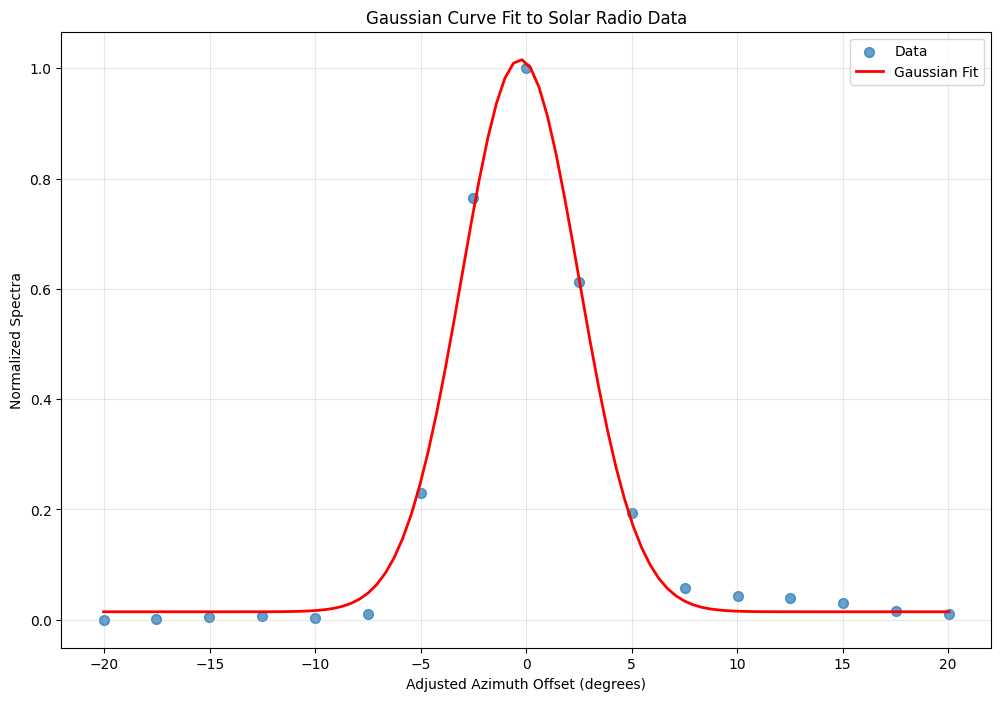

R-squared: 0.9963


In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np

# Define Gaussian function with offset
def gaussian_with_offset(x, amplitude, mean, std_dev, offset):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2)) + offset

# Use the normalized data from tuples directly
# Extract and sort the data properly
az_raw = []
spec_raw = []
for i in tuples:
    az_raw.append(i[0])
    spec_raw.append(i[1])

# Convert to numpy arrays and apply elevation correction
az_raw = np.array(az_raw)
spec_raw = np.array(spec_raw)
x_data = az_raw * np.cos(np.radians(33.4))  # Apply elevation correction
y_data = spec_raw

# Sort data by x_data to ensure proper ordering
sort_indices = np.argsort(x_data)
x_data = x_data[sort_indices]
y_data = y_data[sort_indices]

print(f"X data range: {min(x_data):.2f} to {max(x_data):.2f}")
print(f"Y data range: {min(y_data):.4f} to {max(y_data):.4f}")

# Better initial parameter guesses
max_idx = np.argmax(y_data)
initial_guess = [
    np.max(y_data) - np.min(y_data),  # amplitude (peak minus baseline)
    x_data[max_idx],  # mean (x at max y)
    (np.max(x_data) - np.min(x_data)) / 4,  # std_dev (quarter of data range)
    np.min(y_data)  # offset (baseline)
]

print(f"Initial guesses: amplitude={initial_guess[0]:.4f}, mean={initial_guess[1]:.4f}, std={initial_guess[2]:.4f}, offset={initial_guess[3]:.4f}")

try:
    # Perform the curve fit
    popt, pcov = curve_fit(gaussian_with_offset, x_data, y_data, p0=initial_guess)
    
    # Extract fitted parameters
    amplitude_fit, mean_fit, std_dev_fit, offset_fit = popt
    
    # Calculate parameter uncertainties (standard errors)
    param_errors = np.sqrt(np.diag(pcov))
    
    print(f"\nFitted Gaussian Parameters:")
    print(f"Amplitude: {amplitude_fit:.4f} ± {param_errors[0]:.4f}")
    print(f"Mean: {mean_fit:.4f} ± {param_errors[1]:.4f}")
    print(f"Standard Deviation: {abs(std_dev_fit):.4f} ± {param_errors[2]:.4f}")
    print(f"Offset: {offset_fit:.4f} ± {param_errors[3]:.4f}")
    print(f"FWHM from Gaussian fit: {2.355 * abs(std_dev_fit):.4f}")
    
    # Generate smooth curve for plotting
    x_smooth = np.linspace(min(x_data), max(x_data), 100)
    y_smooth = gaussian_with_offset(x_smooth, *popt)
    
    # Plot the data and fit
    plt.figure(figsize=(12, 8))
    plt.scatter(x_data, y_data, label='Data', alpha=0.7, s=50)
    plt.plot(x_smooth, y_smooth, 'r-', label='Gaussian Fit', linewidth=2)
    plt.xlabel('Adjusted Azimuth Offset (degrees)')
    plt.ylabel('Normalized Spectra')
    plt.title('Gaussian Curve Fit to Solar Radio Data')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Calculate R-squared for goodness of fit
    y_pred = gaussian_with_offset(x_data, *popt)
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"R-squared: {r_squared:.4f}")
    
except Exception as e:
    print(f"Curve fitting failed: {e}")
    print("Data points:")
    for i in range(len(x_data)):
        print(f"x={x_data[i]:.2f}, y={y_data[i]:.4f}")

Fitted parameters:
Amplitude: 0.9849
Center: -0.2832
Scale: 0.4767
Offset: 0.0138


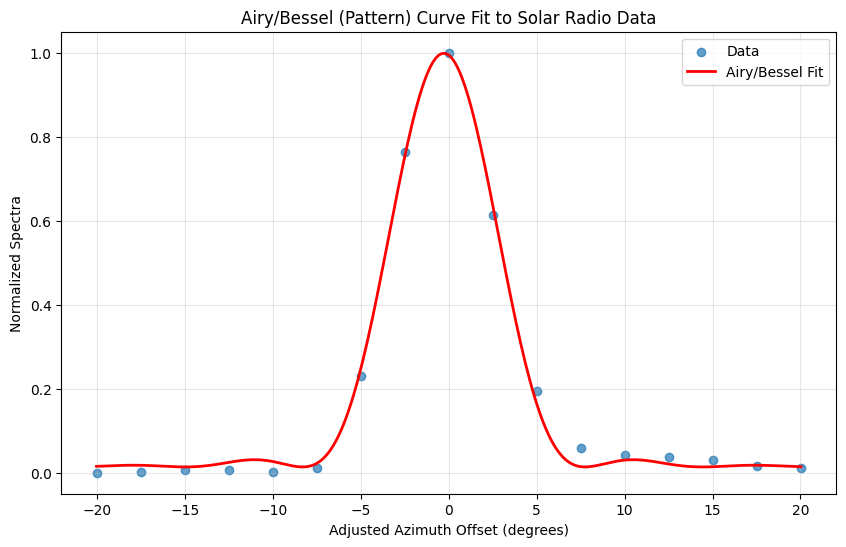

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.special as sp

# Pattern function (Airy/Bessel)
def Pattern(x):
    # Avoid division by zero
    x = np.where(x == 0, 1e-10, x)
    return (2 * (sp.j1(x) / x))**2

# Model to fit: amplitude * Pattern(scale * (x - center)) + offset
def airy_model(x, amplitude, center, scale, offset):
    return amplitude * Pattern(scale * (x - center)) + offset

# Prepare data (use your elevation-corrected and sorted data)
az_raw = []
spec_raw = []
for i in tuples:
    az_raw.append(i[0])
    spec_raw.append(i[1])

az_raw = np.array(az_raw)
spec_raw = np.array(spec_raw)
x_data = az_raw * np.cos(np.radians(33.4))
y_data = spec_raw

sort_indices = np.argsort(x_data)
x_data = x_data[sort_indices]
y_data = y_data[sort_indices]

# Initial parameter guesses
amplitude_guess = np.max(y_data) - np.min(y_data)
center_guess = x_data[np.argmax(y_data)]
scale_guess = 1.0
offset_guess = np.min(y_data)
initial_guess = [amplitude_guess, center_guess, scale_guess, offset_guess]

# Fit the model
popt, pcov = curve_fit(airy_model, x_data, y_data, p0=initial_guess, maxfev=10000)
amplitude_fit, center_fit, scale_fit, offset_fit = popt

print(f"Fitted parameters:")
print(f"Amplitude: {amplitude_fit:.4f}")
print(f"Center: {center_fit:.4f}")
print(f"Scale: {scale_fit:.4f}")
print(f"Offset: {offset_fit:.4f}")

# Plot
x_smooth = np.linspace(min(x_data), max(x_data), 300)
y_smooth = airy_model(x_smooth, *popt)

plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, label='Data', alpha=0.7)
plt.plot(x_smooth, y_smooth, 'r-', label='Airy/Bessel Fit', linewidth=2)
plt.xlabel('Adjusted Azimuth Offset (degrees)')
plt.ylabel('Normalized Spectra')
plt.title('Airy/Bessel (Pattern) Curve Fit to Solar Radio Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# After fitting:
scale_fit = popt[2]
scale_error = np.sqrt(pcov[2, 2])

# Find x where Pattern(x) = 0.5
from scipy.optimize import brentq
def Pattern(x):
    x = np.where(x == 0, 1e-10, x)
    return (2 * (sp.j1(x) / x))**2

x_half = brentq(lambda x: Pattern(x) - 0.5, 1, 10)  # Find positive root
print(x_half)

# FWHM in x_data units (degrees)
FWHM = 2 * x_half / scale_fit
FWHM_error = abs(FWHM * (scale_error / scale_fit))

# Combine with pointing error (conservative, add in quadrature)
pointing_error = 0.5
FWHM_total_error = np.sqrt(FWHM_error**2 + pointing_error**2)

print(f"FWHM: {FWHM:.3f} ± {FWHM_total_error:.3f} degrees")

1.6163399483107028
FWHM: 6.781 ± 0.521 degrees
